In [2]:
## "import" means: bring in a tool that someone else already built, so we can use it.
# pandas is a tool specifically for working with spreadsheet-like data (rows and columns).
# We are giving it a short nickname, "pd", so we don't have to type "pandas" every time.
import pandas as pd

In [3]:
#The rule is specifically: you only need r when your string contains backslashes
# pd.read_csv() opens a CSV file and turns it into a table Python can work with.
# Here we type the full file path directly, instead of storing it in a separate variable first.
# The "r" before the quotation marks tells Python: "treat this text exactly as written,
# don't try to interpret the backslashes specially." This is needed because Windows paths use backslashes.
per = pd.read_csv(r"C:\Users\dell\Documents\Projects\paid-or-unpaid-flfpr\data\Data_in_CSV\cperv12025.csv", low_memory=False)

# Same idea, now for the household file
hh = pd.read_csv(r"C:\Users\dell\Documents\Projects\paid-or-unpaid-flfpr\data\Data_in_CSV\chhv12025.csv" , low_memory=False)

In [4]:
# Check that both loaded correctly by printing how many rows each has
print(len(per))
print(len(hh))

1148634
270472


In [5]:
print(per.columns.tolist())

['file_id', 'sch', 'qtr', 'month', 'visit', 'sec', 'st', 'dc', 'nss_reg', 'bstrm', 'strm', 'grp', 'sstrm', 'sro', 'mfsu', 'sss', 'ssu', 'srl', 'rel', 'sex', 'age', 'marst', 'gedu_lvl', 'tedu_lvl', 'grade', 'yrsbef1', 'yrsaft', 'iflastyr', 'mnths', 'curr_att', 'secondary', 'voc', 'trg', 'trg_com', 'voc_compl', 'voc_fld', 'voc_dur', 'voc_typ', 'voc_fund', 'voc_cert', 'pas', 'ind_pas', 'ocu_pas', 'has_sas', 'loc_pas', 'etyp_pas', 'wrkr_pas', 'job_pas', 'leave_pas', 'ssec_pas', 'ecoprd_pas', 'sas', 'ind_sas', 'ocu_sas', 'loc_sas', 'etyp_sas', 'wrkr_sas', 'job_sas', 'leave_sas', 'ssec_sas', 'ecoprd_sas', 'wrk_365', 'dur_pas', 'dur_sas', 'eff_pas', 'dur_unp', 'evr_wrk', 'rea_nw', 'rea', 'das17', 'ind17', 'hr17', 'ern17', 'das27', 'ind27', 'hr27', 'ern27', 'hr7', 'ahr7', 'das16', 'ind16', 'hr16', 'ern16', 'das26', 'ind26', 'hr26', 'ern26', 'hr6', 'ahr6', 'das15', 'ind15', 'hr15', 'ern15', 'das25', 'ind25', 'hr25', 'ern25', 'hr5', 'ahr5', 'das14', 'ind14', 'hr14', 'ern14', 'das24', 'ind24', 'h

In [6]:
print(hh.columns.tolist())

['file_id', 'sch', 'qtr', 'month', 'visit', 'sec', 'st', 'dc', 'nss_reg', 'bstrm', 'strm', 'grp', 'sstrm', 'sro', 'mfsu', 'sss', 'ssu', 'smonth', 'resp_code', 'svc', 'rea_sub', 'hh_size', 'hhtype', 'relg', 'sg', 'hce1', 'hce2', 'hce3', 'hce4', 'hce5', 'hce_tot', 'lposs', 'llease', 'rent', 'interest', 'pension', 'remit', 'inc_tot', 'inf_srl', 'sur_date', 'sur_time', 'nsc', 'mult', 'totalsd', 'zst', 'caph', 'smallh', 'panel']


In [7]:
# We are creating the "women" table directly from "per" (the original full person file),
# using three conditions at once, joined together with & ("AND").
# Every row must satisfy ALL three conditions to be kept.
#
# per.sec == 1              -> sec column equals 1, which means "rural"
# per.sex == 2               -> sex column equals 2, which means "female"
# per.age.between(25, 54)    -> age column is between 25 and 54, including both endpoints
#
# Each condition is wrapped in its own round brackets ( ) — this is required by pandas
# whenever you combine more than one condition using &.
women = per[(per.sec == 1) & (per.sex == 2) & (per.age.between(25, 54))]

# Print how many rows are left, to double check the result
print("Number of rural women, age 25 to 54:", len(women))

Number of rural women, age 25 to 54: 137552


In [8]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Before we filter our data based on the "acws" column, we want to
# actually SEE what values are inside it first. This is good practice —
# never filter or build something on top of a column until you've
# looked at it with your own eyes at least once.
# ---------------------------------------------------------------

# women.acws
# This means: "go into the 'women' table, and pull out just the 'acws' column."
# Right now, women.acws is just a long list of numbers — one number for every
# single row (every woman) in our "women" table. Most of these numbers will repeat,
# since there are only a handful of possible activity codes (11, 12, 21, 31, etc.)
# shared across 137,552 women.

# .value_counts()
# This is a ready-made pandas function that does something very useful:
# it looks at that long list of repeating numbers, and instead of showing
# us all 137,552 of them one by one (which would be useless), it groups
# them together and counts how many times each DIFFERENT value appears.
#
# The result will look something like a small table with two columns:
#   - the first column shows each unique code that appears (like 11, 21, 31...)
#   - the second column shows how many women in our data have that exact code
#
# It will also automatically be sorted from the MOST common code at the top,
# down to the LEAST common code at the bottom — so we don't have to sort it ourselves.

# print(...)
# This simply displays the result on the screen below the cell, so we can read it.
# Without print(), some outputs show automatically in a notebook, but it's a
# good habit to always use print() explicitly, so you never wonder why
# something didn't show up.

print(women.acws.value_counts())

# ---------------------------------------------------------------
# WHAT WE ARE LOOKING FOR IN THE OUTPUT:
# We expect to see mostly these codes, since they are the ones our
# research plan cares about:
#   11, 12  -> self-employed (paid)
#   31      -> regular wage/salary (paid)
#   41, 42, 51 -> casual labour (paid)
#   21      -> unpaid helper (NOT paid)
# We may also see other codes like 81 (unemployed) or 91-97 (not working
# at all, e.g. housework, studying) — these represent women who are NOT
# currently working, and we will filter them out in the very next step,
# once we've seen this output and confirmed nothing looks unexpected.
# ---------------------------------------------------------------

acws
92    42791
11    26477
21    22850
93    21427
51     9832
31     8005
81     1445
94      915
42      801
95      612
62      430
82      400
91      368
12      362
72      302
41      215
97      119
98      110
61       62
71       29
Name: count, dtype: int64


In [9]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Narrow "women" down further, keeping only rows where a woman was
# actually working in the last 7 days. We checked the official PLFS
# rulebook, which confirms these 7 codes are the ones that count as
# "employed": 11, 12, 21, 31, 41, 42, 51. Every other code (like 61,
# 71, 81, 92, etc.) means something else — unemployed, temporarily
# off work, or not in the labour force at all — and we don't want
# any of those in our sample, since our project is only about women
# who are currently working.
# ---------------------------------------------------------------

# working_codes is a plain Python list — just a container holding several numbers.
# We are listing every acws code that the official rulebook confirms means
# "this person did some form of work" (paid or unpaid) in the last 7 days.
working_codes = [11, 12, 21, 31, 41, 42, 51]

# women.acws.isin(working_codes)
# .isin() checks each row's acws value one by one, and asks:
# "is this value found anywhere inside working_codes?"
# It returns True for a row if the answer is yes, and False if not.
#
# women[ ... ] then keeps only the rows where the answer was True —
# exactly the same filtering pattern we've used before with == and .between().
women = women[women.acws.isin(working_codes)]

# Check how many working women are left after this filter.
# This should be smaller than 137,552 (our count before this step),
# since we are now excluding women who aren't currently working at all.
print("Number of currently working rural women, age 25-54:", len(women))

Number of currently working rural women, age 25-54: 68542


In [10]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Create a brand new column called "paid" in our "women" table.
# It will hold just two possible values: 1 (meaning paid) or 0 (meaning unpaid).
#
# From the official rulebook, we know:
#   - code 21 means "unpaid helper in household enterprise" -> this is our UNPAID case
#   - codes 11, 12, 31, 41, 42, 51 all mean some form of paid work -> our PAID case
#
# Since we already filtered "women" down to ONLY these 7 working codes in the
# previous step, there's a simple shortcut: anyone who is NOT code 21 must be
# one of the 6 paid codes. So we don't need to list all 6 paid codes separately —
# we can just check "is this NOT 21".
# ---------------------------------------------------------------

# women.acws != 21
# The != symbol means "is not equal to". This checks, for every row, whether
# the acws code is anything other than 21.
# This gives us a column of True/False values: True where she's paid, False where unpaid.
#
# .astype(int)
# This converts True -> 1 and False -> 0. We do this because it's easier to work
# with plain numbers (1s and 0s) than True/False values when we build our model later.
women['paid'] = (women.acws != 21).astype(int)

# Let's check how many women fall into each group.
# .value_counts() will now show us how many women have paid = 1, and how many have paid = 0.
print(women.paid.value_counts())

paid
1    45692
0    22850
Name: count, dtype: int64


C:\Users\dell\AppData\Local\Temp\ipykernel_16468\393658544.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  women['paid'] = (women.acws != 21).astype(int)


In [11]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Before building our "married" variable, look at what raw values
# exist in the "marst" (marital status) column, and how common each is.
# ---------------------------------------------------------------

print(women.marst.value_counts())

marst
2    60292
3     5440
1     2153
4      657
Name: count, dtype: int64


In [12]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Create a new column called "married", holding 1 if she is currently
# married, and 0 for anything else (never married, widowed, divorced/separated).
#
# From the official rulebook: code 2 in "marst" means "currently married."
# ---------------------------------------------------------------

# women.marst == 2
# This checks each row: is the marst code exactly equal to 2?
# Result is a column of True/False values.
#
# .astype(int)
# Converts True -> 1 and False -> 0, same idea as our "paid" column.
women['married'] = (women.marst == 2).astype(int)

# Check the counts - this should match the marst breakdown above:
# married=1 should equal exactly the count of marst==2 (60,292),
# and married=0 should equal everyone else combined (5,440 + 2,153 + 657 = 8,250).
print(women.married.value_counts())

married
1    60292
0     8250
Name: count, dtype: int64


C:\Users\dell\AppData\Local\Temp\ipykernel_16468\177295888.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  women['married'] = (women.marst == 2).astype(int)


In [13]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Look at the raw values in "gedu_lvl" (general education level)
# before we group them into simple bands.
# ---------------------------------------------------------------

print(women.gedu_lvl.value_counts().sort_index())

gedu_lvl
1     23869
2       141
3         2
4        33
5      4818
6     10842
7     12055
8      6997
10     5041
11      384
12     3195
13     1165
Name: count, dtype: int64


In [14]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Group the 13 detailed education codes into 3 simple bands, to keep
# our project easy to explain. We use a Python "dictionary" to do this
# — a dictionary is just a lookup table: for every raw code (on the left),
# it tells Python what simple label to use instead (on the right).
# ---------------------------------------------------------------

# EDU_MAP is a dictionary. The { } curly brackets hold a list of
# "key: value" pairs, separated by commas.
# Each "key" (left side, before the colon) is one of the raw gedu_lvl codes.
# Each "value" (right side, after the colon) is the simple band name we want
# to replace it with.
EDU_MAP = {
    1: 'up_to_middle', 2: 'up_to_middle', 3: 'up_to_middle', 4: 'up_to_middle',
    5: 'up_to_middle', 6: 'up_to_middle', 7: 'up_to_middle',
    8: 'secondary_plus', 10: 'secondary_plus', 11: 'secondary_plus',
    12: 'graduate_plus', 13: 'graduate_plus'
}

# .map(EDU_MAP)
# This goes through every row's gedu_lvl value, looks it up in our dictionary,
# and replaces it with the matching simple label. It's like a find-and-replace,
# but done automatically for the whole column at once.
women['edu_band'] = women.gedu_lvl.map(EDU_MAP)

# Check the result - the three band totals should add up to 68,542
print(women.edu_band.value_counts())

edu_band
up_to_middle      51760
secondary_plus    12422
graduate_plus      4360
Name: count, dtype: int64


C:\Users\dell\AppData\Local\Temp\ipykernel_16468\636886910.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  women['edu_band'] = women.gedu_lvl.map(EDU_MAP)


In [15]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Before building anything, just double check the "age" column in the
# FULL person file (per) looks sensible - specifically, that it does
# contain young children (ages 0-5), since our filtered "women" table
# only has ages 25-54 and wouldn't show us this.
# ---------------------------------------------------------------

# per.age.describe() gives us a quick statistical summary of the age column:
# the minimum, maximum, average, and so on - across ALL people, all ages.
print(per.age.describe())

count    1.148634e+06
mean     3.177948e+01
std      1.986666e+01
min      0.000000e+00
25%      1.600000e+01
50%      2.900000e+01
75%      4.600000e+01
max      1.170000e+02
Name: age, dtype: float64


In [16]:
HHKEY = ['sch', 'qtr', 'month', 'visit', 'sec', 'st', 'dc', 'nss_reg',
          'bstrm', 'strm', 'grp', 'sstrm', 'sro', 'mfsu', 'sss', 'ssu']

per['is_child'] = per.age.between(0, 5)

child_flag = per.groupby(HHKEY)['is_child'].any().reset_index()
child_flag = child_flag.rename(columns={'is_child': 'child_u6'})

print(child_flag.head())
print("\nNumber of households in this table:", len(child_flag))

C:\Users\dell\AppData\Local\Temp\ipykernel_16468\3888980566.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  per['is_child'] = per.age.between(0, 5)


   sch qtr  month visit  sec  st  dc  nss_reg bstrm  strm  grp  sstrm  sro  \
0  104  Q1      1    V1    1   1   1       13  D001     1    2      1  122   
1  104  Q1      1    V1    1   1   1       13  D001     1    2      1  122   
2  104  Q1      1    V1    1   1   1       13  D001     1    2      1  122   
3  104  Q1      1    V1    1   1   1       13  D001     1    2      1  122   
4  104  Q1      1    V1    1   1   1       13  D001     1    2      1  122   

    mfsu  sss  ssu  child_u6  
0  10852    1    1     False  
1  10852    1    2     False  
2  10852    1    3     False  
3  10852    1    4     False  
4  10852    2    1     False  

Number of households in this table: 270472


In [17]:
# Check how many households have at least one young child, vs how many don't
print(child_flag.child_u6.value_counts())

child_u6
False    201059
True      69413
Name: count, dtype: int64


In [18]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Attach the child_u6 column (which lives in the separate "child_flag"
# table, one row per household) onto our "women" table (one row per
# working woman), by matching up households using HHKEY.
# ---------------------------------------------------------------

# .merge() combines two tables into one, by matching rows where the
# specified columns are equal in both tables.
#
# women.merge(child_flag, ...) means: "start with the women table,
# and for each row, look up the matching household in child_flag,
# then attach that household's extra columns onto this row."
#
# on=HHKEY tells pandas exactly which columns to use for the matching -
# the same 16-column "address" we used to build child_flag in the first place.
#
# how='left' means: "keep every single row from women, no matter what -
# even if, for some reason, a matching household isn't found in child_flag."
# This is a safety setting, so we don't accidentally lose any of our
# 68,542 women during this step.
women = women.merge(child_flag, on=HHKEY, how='left')

# Check that we still have exactly 68,542 rows (no women lost or duplicated),
# and look at the new child_u6 breakdown specifically among our working women.
print("Number of rows after merge:", len(women))
print(women.child_u6.value_counts())

Number of rows after merge: 68542
child_u6
False    50393
True     18149
Name: count, dtype: int64


In [20]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Look at the raw values in "lposs" (land possessed) and "hhtype"
# (household type), before building our land and household-type variables.
# ---------------------------------------------------------------

print("Land possessed codes:")
print(hh.lposs.value_counts().sort_index())

print("\nHousehold type codes:")
print(hh.hhtype.value_counts().sort_index())

Land possessed codes:
lposs
1     253877
2       6501
3       3570
4       1897
5       2106
6       1342
7        566
8        255
10       187
11        89
12        76
99         6
Name: count, dtype: int64

Household type codes:
hhtype
1    102853
2     77515
3     37723
4      9776
5     19881
9     22724
Name: count, dtype: int64


In [22]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Create a simple yes/no column in the household file: does this
# household possess a meaningful amount of land, or not?
# We treat codes 1 and 2 (under 0.05 acres) as "no real land" - barely
# more than a house plot, not a farm. Code 99 (others/houseless) also
# counts as "no land". Codes 3 and above mean a real farm plot.
# ---------------------------------------------------------------

# hh.lposs >= 3   -> keep codes 3 and above (0.05 acres or more)
# hh.lposs <= 12  -> exclude code 99, so it doesn't get wrongly counted as "has land"
# & combines both conditions - both must be true for has_land to be 1
hh['has_land'] = ((hh.lposs >= 3) & (hh.lposs <= 12)).astype(int)

# Check the split between households with land and without
print(hh.has_land.value_counts())

has_land
0    260384
1     10088
Name: count, dtype: int64


In [27]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Group the 6 detailed household-type codes into simple categories,
# using a dictionary lookup - the same idea as EDU_MAP earlier.
#
# From the official rulebook:
#   1 = self-employed in agriculture      -> "farming"
#   2 = self-employed in non-agriculture  -> "other_self_employed"
#   3 = regular wage/salary               -> "works_for_someone"
#   4 = casual labour, agriculture        -> "works_for_someone"
#   5 = casual labour, non-agriculture    -> "works_for_someone"
#   9 = others                            -> "unclear" (kept separate,
#       since we don't actually know what this category means)
# ---------------------------------------------------------------

HH_MAP = {
    1: 'farming',
    2: 'other_self_employed',
    3: 'works_for_someone',
    4: 'works_for_someone',
    5: 'works_for_someone',
    9: 'unclear'
}

# Same .map() idea as before: look up each hhtype code in HH_MAP,
# and replace it with the matching simple label.
hh['hh_group'] = hh.hhtype.map(HH_MAP)

# Check the result
print(hh.hh_group.value_counts())

hh_group
farming                102853
other_self_employed     77515
works_for_someone       67380
unclear                 22724
Name: count, dtype: int64


In [28]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Attach has_land and hh_group (both currently sitting in the household
# table "hh") onto our "women" table, by matching households using HHKEY -
# the same merging idea we used for child_u6.
# ---------------------------------------------------------------

# hh[HHKEY + ['has_land', 'hh_group']]
# This selects, from the household table, only the columns we actually
# need for this merge: the 16 HHKEY columns (needed to match households),
# plus the two new columns we just built.
# The + here is just joining two Python lists together into one longer list.
#
# women.merge(..., on=HHKEY, how='left')
# Same idea as before: attach the matching household's has_land and
# hh_group values onto each woman's row, using HHKEY to find the right match.
# how='left' means we keep every one of our 68,542 women no matter what.
women = women.merge(hh[HHKEY + ['has_land', 'hh_group']], on=HHKEY, how='left')

# Check we still have exactly 68,542 rows, and look at the new columns
# specifically among our working women.
print("Number of rows after merge:", len(women))
print(women.has_land.value_counts())
print(women.hh_group.value_counts())

Number of rows after merge: 68542
has_land
0    66897
1     1645
Name: count, dtype: int64
hh_group
farming                32303
works_for_someone      25430
other_self_employed    10761
unclear                   48
Name: count, dtype: int64


In [30]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Group the month of survey (1-12) into 3 simple agricultural seasons:
#   lean season    -> April, May, June        (months 4, 5, 6)
#   kharif season  -> July, Aug, Sep, Oct      (months 7, 8, 9, 10)
#   rabi season    -> Nov, Dec, Jan, Feb, Mar  (months 11, 12, 1, 2, 3)
# ---------------------------------------------------------------

# pd.cut() takes a column of numbers and slices it into groups, based on
# "bin edges" we give it. Here, bins=[0, 3, 6, 10, 12] creates 4 slices:
#   (0 to 3], (3 to 6], (6 to 10], (10 to 12]
# We give each slice a label - but since rabi wraps around the year
# (Nov-Mar spans both the "10-12" slice AND the "0-3" slice), we
# assign the SAME label 'rabi' to both the first and last slice.
women['season'] = pd.cut(women.month, bins=[0, 3, 6, 10, 12],
                          labels=['rabi', 'lean', 'kharif', 'rabi'],
                          ordered=False)

# Check the result
print(women.season.value_counts())

season
rabi      29096
kharif    23280
lean      16166
Name: count, dtype: int64


C:\Users\dell\AppData\Local\Temp\ipykernel_16468\1960645005.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  women['season'] = pd.cut(women.month, bins=[0, 3, 6, 10, 12],


In [32]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Look at the raw state codes in our "women" table, before we group
# them into 6 broad zones. "st" has been sitting in our table since
# the very beginning - it's one of the HHKEY columns - we just haven't
# used it yet.
# ---------------------------------------------------------------

print(women.st.value_counts().sort_index())

st
1     1453
2     1040
3     1291
5      687
6     1030
7       26
8     6922
9     7468
10    3424
11     289
12     633
13     436
14     524
15     224
16     454
17     667
18    3066
19    2891
20    2114
21    3026
22    2238
23    6362
24    3715
25     142
27    5116
28    2915
29    3530
30      68
31      32
32     803
33    3142
34      57
35     156
36    2436
37     165
Name: count, dtype: int64


In [33]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Group each state code into one of 6 broad regions, using a dictionary
# lookup - same idea as EDU_MAP and HH_MAP before, just a longer list
# since there are more states than education or household-type codes.
# ---------------------------------------------------------------

ZONE_MAP = {
    1: 'North', 2: 'North', 3: 'North', 5: 'North', 6: 'North', 7: 'North', 37: 'North',
    9: 'Central', 23: 'Central', 22: 'Central',
    10: 'East', 20: 'East', 19: 'East', 21: 'East',
    8: 'West', 24: 'West', 27: 'West', 30: 'West', 25: 'West',
    28: 'South', 36: 'South', 29: 'South', 32: 'South', 33: 'South', 34: 'South', 31: 'South', 35: 'South',
    11: 'Northeast', 12: 'Northeast', 13: 'Northeast', 14: 'Northeast',
    15: 'Northeast', 16: 'Northeast', 17: 'Northeast', 18: 'Northeast'
}

# Same .map() idea as before - look up each state code, replace with its zone name.
women['zone'] = women.st.map(ZONE_MAP)

# Check the result
print(women.zone.value_counts())

# Also check: did every single state code get matched to a zone?
# If any codes were missed, this will show a number greater than 0.
print("\nUnmapped rows (should be 0):", women.zone.isna().sum())

zone
Central      16068
West         15963
South        13071
East         11455
Northeast     6293
North         5692
Name: count, dtype: int64

Unmapped rows (should be 0): 0


C:\Users\dell\AppData\Local\Temp\ipykernel_16468\2540055416.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  women['zone'] = women.st.map(ZONE_MAP)


In [34]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Calculate the weighted rural female labour force participation rate
# (LFPR) from our own data, and compare it against the published
# government figure (approximately 46% for CY2025, usual status).
# If our number is close, it confirms our filtering and codes are correct.
# ---------------------------------------------------------------

# For this specific check, we need ALL rural women aged 15+, not just our
# working, 25-54 sample - because the published 46% figure covers that
# broader group. So we build this from "per" (the original full file),
# not from "women".
check = per[(per.sec == 1) & (per.sex == 2) & (per.age >= 15)].copy()

# A woman counts as "in the labour force" (working OR seeking work) if her
# usual principal status (pas) OR usual subsidiary status (sas) is one of
# the working codes, or if she's unemployed (code 81).
working_codes = [11, 12, 21, 31, 41, 42, 51]
check['in_labour_force'] = (check.pas.isin(working_codes + [81])) | (check.sas.isin(working_codes))

# Now calculate the WEIGHTED share - using mult, not just a plain count,
# since some women represent more real people than others.
# (check.in_labour_force * check.mult).sum()  ->  total weighted "yes" count
# check.mult.sum()                             ->  total weighted population
weighted_lfpr = 100 * (check.in_labour_force * check.mult).sum() / check.mult.sum()

print(f"Our calculated rural female LFPR (age 15+): {weighted_lfpr:.1f}%")
print("Published government figure: approximately 46%")

Our calculated rural female LFPR (age 15+): 45.9%
Published government figure: approximately 46%


In [35]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# The "mult" column represents how many real people each surveyed woman
# stands for - added up across everyone, mult sums to something close
# to the entire population, which is a number in the tens of millions.
# If we feed that raw into a model, the model will wrongly believe it
# has tens of millions of real observations, making it absurdly
# overconfident. We fix this by rescaling "mult" so it adds up to
# exactly our actual sample size (68,542) instead.
# ---------------------------------------------------------------

# women.mult.sum()  -> the total of all weights added together (a huge number)
# len(women)         -> our actual number of rows (68,542)
# Multiplying each woman's weight by (68542 / huge_number) shrinks every
# weight down proportionally, so they still reflect each other correctly
# (someone with 2x the weight of another still has 2x after rescaling),
# but the new total adds up to exactly 68,542.
women['w'] = women['mult'] * len(women) / women['mult'].sum()

# Check: this should print something very close to 68542.0
print("Sum of rescaled weights:", women['w'].sum())
print("Actual number of rows:", len(women))

Sum of rescaled weights: 68542.0
Actual number of rows: 68542


C:\Users\dell\AppData\Local\Temp\ipykernel_16468\1896155985.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  women['w'] = women['mult'] * len(women) / women['mult'].sum()


edu_band
up_to_middle      0.669085
secondary_plus    0.701133
graduate_plus     0.805515
dtype: float64


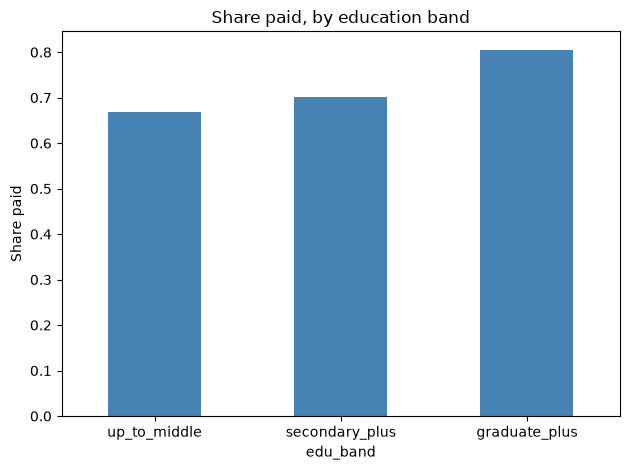

In [53]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# For each education band, calculate the WEIGHTED share of women who
# are paid (not just a plain average, since some women represent more
# real people than others).
# ---------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

# A small helper function: given a group of rows, calculate the
# weighted average of "paid" using that group's own weights.
# np.average() with the weights= option does exactly this -
# it's like a normal average, but rows with bigger weights count more.
def weighted_paid_share(group):
    return np.average(group['paid'], weights=group['w'])

# women.groupby('edu_band') splits our table into 3 small groups,
# one per education band (same groupby idea as HHKEY earlier, just
# grouping by one column this time instead of 16).
#
# .apply(weighted_paid_share) runs our helper function separately on
# EACH of those 3 groups, and collects the 3 results together.
edu_order = ['up_to_middle', 'secondary_plus', 'graduate_plus']
paid_by_edu = women.groupby('edu_band', observed=True).apply(weighted_paid_share)
paid_by_edu = paid_by_edu.reindex(edu_order)  # puts them in a sensible order

print(paid_by_edu)

# Draw a simple bar chart of these 3 numbers
paid_by_edu.plot(kind='bar', title='Share paid, by education band', color='steelblue')
plt.ylabel('Share paid')
plt.xticks(rotation=0)
plt.tight_layout()
# plt.savefig() saves the chart as an actual image file, in the
# "charts" folder we created at the start of this project.
# We do this BEFORE plt.show(), otherwise the chart gets cleared
# from memory and there's nothing left to save.
plt.savefig(r"C:\Users\dell\Documents\Projects\paid-or-unpaid-flfpr\charts\education_chart.png", dpi=150)
plt.show()

has_land         0         1
season                      
lean      0.712873  0.736356
kharif    0.672087  0.737415
rabi      0.670644  0.752021


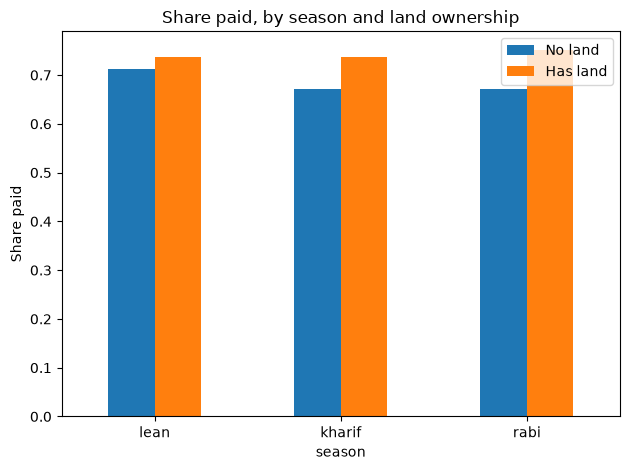

In [54]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Calculate the weighted share paid, broken down by TWO things at once:
# season, AND whether the household has land. This lets us see if the
# season effect looks different for land-owning vs landless households.
# ---------------------------------------------------------------

# groupby(['season', 'has_land']) groups by BOTH columns together -
# so instead of 3 groups (one per season) or 2 groups (land/no land),
# we get up to 6 groups: every combination of the two.
season_land = women.groupby(['season', 'has_land'], observed=True).apply(weighted_paid_share)

# .unstack() reshapes this from one long list into a small table,
# with season as rows and has_land (0/1) as columns - much easier to read.
season_land = season_land.unstack()

# Put the seasons in a sensible order (lean -> kharif -> rabi)
season_land = season_land.reindex(['lean', 'kharif', 'rabi'])

print(season_land)

# Draw a grouped bar chart: one pair of bars per season, comparing
# landless (0) vs has-land (1) households
season_land.plot(kind='bar', title='Share paid, by season and land ownership')
plt.ylabel('Share paid')
plt.legend(['No land', 'Has land'])
plt.xticks(rotation=0)
plt.tight_layout()
# plt.savefig() saves the chart as an actual image file, in the
# "charts" folder we created at the start of this project.
# We do this BEFORE plt.show(), otherwise the chart gets cleared
# from memory and there's nothing left to save.
plt.savefig(r"C:\Users\dell\Documents\Projects\paid-or-unpaid-flfpr\charts\season_land_chart.png", dpi=150)
plt.show()

hh_group
farming                0.501181
other_self_employed    0.702259
works_for_someone      0.880280
unclear                0.232660
dtype: float64


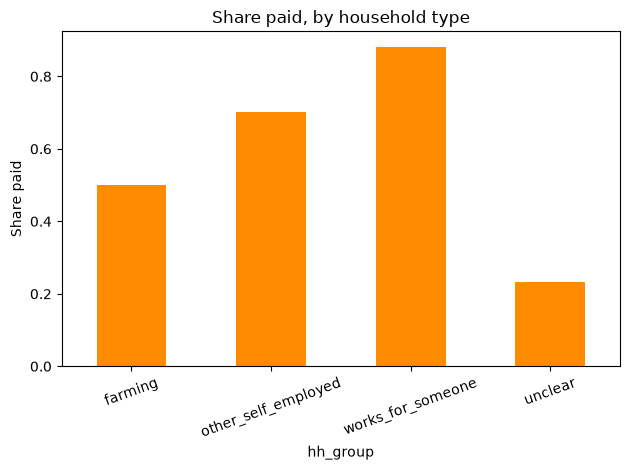

In [55]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Calculate the weighted share paid, separately for each household type
# (farming, other self-employed, works for someone, unclear).
# ---------------------------------------------------------------

hh_order = ['farming', 'other_self_employed', 'works_for_someone', 'unclear']
paid_by_hhgroup = women.groupby('hh_group', observed=True).apply(weighted_paid_share)
paid_by_hhgroup = paid_by_hhgroup.reindex(hh_order)

print(paid_by_hhgroup)

paid_by_hhgroup.plot(kind='bar', title='Share paid, by household type', color='darkorange')
plt.ylabel('Share paid')
plt.xticks(rotation=20)
plt.tight_layout()
# plt.savefig() saves the chart as an actual image file, in the
# "charts" folder we created at the start of this project.
# We do this BEFORE plt.show(), otherwise the chart gets cleared
# from memory and there's nothing left to save.
plt.savefig(r"C:\Users\dell\Documents\Projects\paid-or-unpaid-flfpr\charts\household_type_chart.png", dpi=150)
plt.show()

In [39]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Build a summary table showing the weighted average of each of our
# variables, split by paid (1) vs unpaid (0) women. This is a broad
# sanity check across everything at once.
# ---------------------------------------------------------------

# A small helper function, similar to before, but this time it takes
# the weighted average of WHATEVER column we give it, not just "paid".
def weighted_avg(group, col):
    return np.average(group[col], weights=group['w'])

# For each of these simple yes/no or numeric columns, calculate the
# weighted average separately for paid=0 and paid=1 women.
summary = pd.DataFrame({
    'married':   women.groupby('paid')['married'].apply(lambda g: np.average(g, weights=women.loc[g.index, 'w'])),
    'child_u6':  women.groupby('paid')['child_u6'].apply(lambda g: np.average(g, weights=women.loc[g.index, 'w'])),
    'has_land':  women.groupby('paid')['has_land'].apply(lambda g: np.average(g, weights=women.loc[g.index, 'w'])),
})

print(summary.round(3))

      married  child_u6  has_land
paid                             
0       0.959     0.307     0.019
1       0.846     0.244     0.025


In [41]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Prepare a clean version of our data specifically for the model.
# Two small decisions to make first:
#
# 1) Drop the "unclear" household-type group (only 48 women - too small
#    and too uncertain in meaning to include reliably in the model).
#
# 2) Tell Python the ORDER of categories for our text columns
#    (edu_band, hh_group, season, zone), so the model knows which
#    category to treat as the "baseline" to compare everything else
#    against. Without doing this, Python would just pick an order
#    alphabetically, which can make results harder to read.
# ---------------------------------------------------------------

# Step 2a: drop the "unclear" household type rows
model_df = women[women.hh_group != 'unclear'].copy()
print("Rows before dropping 'unclear':", len(women))
print("Rows after dropping 'unclear':", len(model_df))

# Step 2b: fix the category order for each text column.
# pd.CategoricalDtype() lets us specify an exact list and order.
# Whichever category is listed FIRST becomes the "baseline" the model
# compares everything else against.
from pandas.api.types import CategoricalDtype

edu_order = CategoricalDtype(['up_to_middle', 'secondary_plus', 'graduate_plus'], ordered=False)
hh_order = CategoricalDtype(['farming', 'other_self_employed', 'works_for_someone'], ordered=False)
season_order = CategoricalDtype(['lean', 'kharif', 'rabi'], ordered=False)
zone_order = CategoricalDtype(['Central', 'North', 'East', 'West', 'South', 'Northeast'], ordered=False)

# .astype() applies these orderings to the actual columns
model_df['edu_band'] = model_df['edu_band'].astype(edu_order)
model_df['hh_group'] = model_df['hh_group'].astype(hh_order)
model_df['season'] = model_df['season'].astype(season_order)
model_df['zone'] = model_df['zone'].astype(zone_order)

print("\nSetup complete. Baseline categories:")
print("Education baseline: up_to_middle")
print("Household type baseline: farming")
print("Season baseline: lean")
print("Zone baseline: Central")

Rows before dropping 'unclear': 68542
Rows after dropping 'unclear': 68494

Setup complete. Baseline categories:
Education baseline: up_to_middle
Household type baseline: farming
Season baseline: lean
Zone baseline: Central


In [42]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Run the logistic regression: measure how much each of our variables
# changes the chance a woman is paid, with everything else held fixed
# at the same time. This is different from our EDA charts, which each
# looked at ONE thing at a time - the model looks at all of them together.
# ---------------------------------------------------------------

import statsmodels.api as sm
import statsmodels.formula.api as smf

# This is a "formula" - a plain-text way of telling statsmodels which
# outcome we're explaining (paid), and which variables to use to explain it.
# The ~ symbol means "is explained by". The + symbols just add more
# variables into the model, one after another.
# C(...) tells statsmodels "this is a category (text), not a number."
formula = 'paid ~ C(edu_band) + married + child_u6 + has_land + C(hh_group) + C(season) + C(zone)'

# smf.glm(...) sets up the model:
#   formula        -> what we defined above
#   data           -> our cleaned model_df table
#   family=sm.families.Binomial()  -> tells statsmodels our outcome is
#                                      yes/no (0 or 1), which is exactly
#                                      what makes this "logistic regression"
#   var_weights    -> use our rescaled survey weight column "w"
#
# .fit() actually runs the calculation and gives us back the finished model.
model = smf.glm(formula, data=model_df,
                 family=sm.families.Binomial(),
                 var_weights=model_df['w']).fit()

# .summary() prints a full results table
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   paid   No. Observations:                68494
Model:                            GLM   Df Residuals:                    68479
Model Family:                Binomial   Df Model:                           14
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -36287.
Date:                Thu, 24 Sep 2026   Deviance:                       72574.
Time:                        23:01:24   Pearson chi2:                 6.72e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1727
Covariance Type:            nonrobust                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

In [43]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Convert the "graduate_plus" education effect from log-odds into a
# plain percentage-point difference, by building one example woman,
# then asking the model to predict her chance of being paid TWICE -
# once with low education, once with graduate education - and looking
# at the difference.
# ---------------------------------------------------------------

# Take one real row from our data as a "template" - we'll just borrow
# her other characteristics (married, land, household type, etc.) and
# only change her education.
template = model_df.iloc[[0]].copy()

# Make two versions: one with up_to_middle education, one with graduate_plus
low_edu = template.copy()
low_edu['edu_band'] = 'up_to_middle'

high_edu = template.copy()
high_edu['edu_band'] = 'graduate_plus'

# model.predict() asks the model: "given this woman's characteristics,
# what's your predicted PROBABILITY (between 0 and 1) that she's paid?"
p_low = model.predict(low_edu).iloc[0]
p_high = model.predict(high_edu).iloc[0]

print(f"Predicted chance of being paid, up_to_middle education: {p_low:.2f}")
print(f"Predicted chance of being paid, graduate_plus education: {p_high:.2f}")
print(f"Difference: {(p_high - p_low)*100:.1f} percentage points")

Predicted chance of being paid, up_to_middle education: 0.48
Predicted chance of being paid, graduate_plus education: 0.58
Difference: 9.5 percentage points


In [44]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Build small reusable functions that do exactly what we just did by
# hand for education, and use them to get a plain percentage-point
# result for every variable in our model.
# ---------------------------------------------------------------

template = model_df.iloc[[0]].copy()

# For a YES/NO (0/1) variable: compare template with it set to 0 vs 1
def ame_binary(varname):
    v0 = template.copy(); v0[varname] = 0
    v1 = template.copy(); v1[varname] = 1
    p0 = model.predict(v0).iloc[0]
    p1 = model.predict(v1).iloc[0]
    return (p1 - p0) * 100

# For a CATEGORY variable: compare template with it set to one category
# vs another category (e.g. baseline vs a specific other option)
def ame_category(varname, base_level, compare_level):
    v0 = template.copy(); v0[varname] = base_level
    v1 = template.copy(); v1[varname] = compare_level
    p0 = model.predict(v0).iloc[0]
    p1 = model.predict(v1).iloc[0]
    return (p1 - p0) * 100

print("Married:", round(ame_binary('married'), 1), "points")
print("Child under 6:", round(ame_binary('child_u6'), 1), "points")
print("Has land:", round(ame_binary('has_land'), 1), "points")
print()
print("Education - secondary_plus vs up_to_middle:", round(ame_category('edu_band', 'up_to_middle', 'secondary_plus'), 1), "points")
print("Education - graduate_plus vs up_to_middle:", round(ame_category('edu_band', 'up_to_middle', 'graduate_plus'), 1), "points")
print()
print("Household type - other_self_employed vs farming:", round(ame_category('hh_group', 'farming', 'other_self_employed'), 1), "points")
print("Household type - works_for_someone vs farming:", round(ame_category('hh_group', 'farming', 'works_for_someone'), 1), "points")
print()
print("Season - lean vs kharif:", round(ame_category('season', 'kharif', 'lean'), 1), "points")
print("Season - rabi vs kharif:", round(ame_category('season', 'kharif', 'rabi'), 1), "points")

Married: -28.2 points
Child under 6: -6.5 points
Has land: 5.2 points

Education - secondary_plus vs up_to_middle: 2.4 points
Education - graduate_plus vs up_to_middle: 9.5 points

Household type - other_self_employed vs farming: 17.6 points
Household type - works_for_someone vs farming: 36.4 points

Season - lean vs kharif: 4.4 points
Season - rabi vs kharif: -0.8 points


In [45]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# The Random Forest needs every column to be a plain number - it can't
# read text labels like "graduate_plus" directly. So we convert each
# text column into a simple number code, using the same dictionary
# lookup idea (.map()) we've used throughout this project.
# ---------------------------------------------------------------

rf_df = model_df.copy()

# For each text column, we assign a number to each category.
# The actual numbers don't carry any special meaning by themselves -
# they're just labels the Random Forest can work with. (This is
# different from our logistic regression, which needed the text
# categories to build a properly interpretable model - the Random
# Forest doesn't need that, since we're only using it to look at
# patterns and importance, not to report percentage-point numbers.)
edu_map_num = {'up_to_middle': 0, 'secondary_plus': 1, 'graduate_plus': 2}
hh_map_num = {'farming': 0, 'other_self_employed': 1, 'works_for_someone': 2}
season_map_num = {'lean': 0, 'kharif': 1, 'rabi': 2}
zone_map_num = {'Central': 0, 'North': 1, 'East': 2, 'West': 3, 'South': 4, 'Northeast': 5}

rf_df['edu_i'] = rf_df['edu_band'].map(edu_map_num)
rf_df['hh_i'] = rf_df['hh_group'].map(hh_map_num)
rf_df['season_i'] = rf_df['season'].map(season_map_num)
rf_df['zone_i'] = rf_df['zone'].map(zone_map_num)

# married, child_u6, and has_land are already plain 0/1 numbers,
# so they don't need converting.

# Check nothing went missing in the conversion (should all print 0)
print("Unmapped education:", rf_df['edu_i'].isna().sum())
print("Unmapped household type:", rf_df['hh_i'].isna().sum())
print("Unmapped season:", rf_df['season_i'].isna().sum())
print("Unmapped zone:", rf_df['zone_i'].isna().sum())

Unmapped education: 0
Unmapped household type: 0
Unmapped season: 0
Unmapped zone: 0


In [46]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Build a Random Forest using the same variables as our logistic
# regression, and fit it to our data. Remember: we are NOT using this
# to predict anything new or to report a final number - only to check,
# afterward, whether it agrees with our logistic regression, and
# whether it notices any pattern the logistic regression might have
# missed (like an effect behaving differently for different women).
# ---------------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier

# "feats" is a list of the column names we want the Random Forest to
# use - the same six ingredients from our research plan, plus zone.
feats = ['edu_i', 'married', 'child_u6', 'has_land', 'hh_i', 'season_i', 'zone_i']

# X is the "inputs" - just these 7 columns.
# y is the "answer" we want it to learn to predict - our paid column.
X = rf_df[feats]
y = rf_df['paid']

# RandomForestClassifier(...) sets up the forest itself, with a few
# settings:
#   n_estimators=200   -> build 200 separate small decision trees
#   max_depth=6         -> keep each tree fairly simple/shallow, so it
#                          doesn't overfit to random noise in the data
#   min_samples_leaf=100 -> each final small group must contain at
#                          least 100 real women, so results aren't
#                          based on just a handful of people
#   random_state=1      -> makes the result reproducible - if we run
#                          this again later, we'll get the exact same
#                          forest, not a slightly different random one
rf = RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=100, random_state=1)

# .fit() actually trains the forest on our data.
# sample_weight=rf_df['w'] tells it to use our rescaled survey weights,
# same idea as var_weights did for the logistic regression.
rf.fit(X, y, sample_weight=rf_df['w'])

print("Random Forest trained successfully on", len(rf_df), "women.")

Random Forest trained successfully on 68494 women.


has_land    0.001577
season_i    0.007753
edu_i       0.016021
child_u6    0.016785
zone_i      0.097675
married     0.128052
hh_i        0.732137
dtype: float64


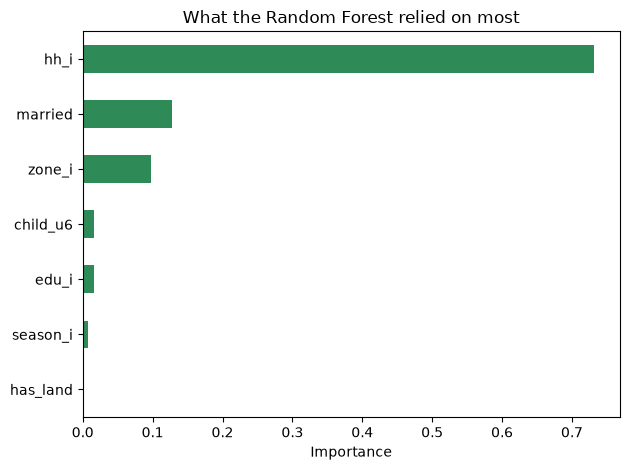

In [47]:
# ---------------------------------------------------------------
# GOAL OF THIS STEP:
# Ask the Random Forest: of these 7 variables, which ones did you rely
# on most to make your guesses? This doesn't tell us WHICH DIRECTION
# an effect goes (unlike our logistic regression) - only how much the
# model leaned on each variable overall. We use this purely as a
# sanity check against our logistic regression results.
# ---------------------------------------------------------------

# rf.feature_importances_ is a list of numbers, one per input variable,
# automatically calculated by the forest after training. Bigger number
# means the forest relied on that variable more.
#
# pd.Series(...) turns this plain list into a labelled table, using
# our "feats" list as the labels, so we can tell which number belongs
# to which variable.
#
# .sort_values() puts them in order, smallest to largest, which makes
# the chart easier to read from least to most important, top to bottom.
importance = pd.Series(rf.feature_importances_, index=feats).sort_values()

print(importance)

# Draw a horizontal bar chart - easier to read variable names on a
# chart like this than a normal vertical bar chart.
importance.plot(kind='barh', title='What the Random Forest relied on most', color='seagreen')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()